# SUB-WP — Pipeline completo de entrenamiento y análisis

**Sistema**: SUB-WP (*Subgoal Waypoint*) — waypoints fijos A* con paso `WP_STEP=1.5m`
**Observación base**: 36 rayos LIDAR (5m, 360°) + 4 estado = **40 dims**
**Fase dinámica (E1.x)**: obs expandida a **48 dims** (+8 dims supervisor)
**Seeds**: 42, 123, 524 | **max_steps por episodio**: 6000

---
Pipeline completo desde Stage 1 hasta E2.2b en orden cronológico.
**Nota**: SUBWP tiene rama r1 (bug dropoff) y rama r2 (corregida). Solo r2 llega a resultados finales.

In [1]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

SUBWP_DIR   = Path("/Users/adrigarcia/tfm-robots-rl/simulacion/controllers/rl_train_SUB_WP_continuo")
TB_DIR      = SUBWP_DIR / "tensorboard_logs"
INFER_DIR   = SUBWP_DIR / "experimentos" / "resultados"
INFER_OLD_DIR = SUBWP_DIR / "inferencia_subwp" / "resultados"
FIGS_DIR    = Path("/Users/adrigarcia/tfm-robots-rl/simulacion/notebooks/figuras")
FIGS_DIR.mkdir(exist_ok=True)
SYSTEM = "SUB-WP"
PREFIX = "subwp"

SEEDS = [42, 123, 524]
SEED_COLORS = {"s42":"#2196F3","s123":"#FF9800","s524":"#4CAF50"}
SEED_LABELS = {"s42":"Seed 42","s123":"Seed 123","s524":"Seed 524"}
COL_FACIL   = "#1565C0"
COL_DIFICIL = "#E64A19"
OUT_COLORS  = {"exito":"#43A047","col_approach":"#E53935","col_exit":"#FF7043",
               "colision":"#E53935","truncado":"#757575"}
OUT_LABELS  = {"exito":"Exito","col_approach":"Col. approach","col_exit":"Col. salida",
               "colision":"Colision","truncado":"Truncado"}
plt.rcParams.update({"figure.dpi":150,"font.size":11,"axes.titlesize":13,"axes.labelsize":11,
    "axes.spines.top":False,"axes.spines.right":False,"legend.framealpha":0.85,
    "figure.facecolor":"white","axes.facecolor":"#FAFAFA","grid.color":"#E0E0E0",
    "grid.linestyle":"--","grid.alpha":0.7})

_ref = pd.read_csv(SUBWP_DIR / "stats_subwp_s42_stage2.csv")
DIFICIL_MAP = dict(zip(_ref["goal_id"], _ref["dificil"].astype(bool)))
GOALS_ORDERED = sorted(DIFICIL_MAP.keys())

VALID_RESULTADOS = {"exito","colision","col_approach","col_exit","col_retorno","col_return","truncado"}

INFER_OLD_FILES = {
    "stage1":    {"s42":"infer_subwp_s42_stage1.csv","s123":"infer_subwp_s123_stage1.csv","s524":"infer_subwp_s524_stage1.csv"},
    "stage2":    {"s42":"infer_subwp_s42_stage2.csv","s123":"infer_subwp_s123_stage2.csv","s524":"infer_subwp_s524_stage2.csv"},
    "stage3_r2": {"s42":"infer_subwp_s42_wp75_r2_stage3.csv","s123":"infer_subwp_s123_wp75_r2_stage3.csv","s524":"infer_subwp_s524_wp75_r2_stage3.csv"},
    "stage4_r2": {"s42":"infer_subwp_s42_wp75_r2_stage4.csv","s123":"infer_subwp_s123_wp75_r2_stage4.csv","s524":"infer_subwp_s524_wp75_r2_stage4.csv"},
    "stage5_r2": {"s42":"infer_subwp_s42_wp75_r2_stage5.csv","s123":"infer_subwp_s123_wp75_r2_stage5.csv","s524":"infer_subwp_s524_wp75_r2_stage5.csv"},
    "din_v1_r1": {"s42":"infer_din_retrained_s42.csv","s123":"infer_din_retrained_s123.csv","s524":"infer_din_retrained_s524.csv"},
    "din_v2_r1": {"s42":"infer_din_v2_s42.csv","s123":"infer_din_v2_s123.csv","s524":"infer_din_v2_s524.csv"},
    "din_v2_cont_r1":{"s42":"infer_din_v2_cont_s42.csv","s123":"infer_din_v2_cont_s123.csv","s524":"infer_din_v2_cont_s524.csv"},
    "din_v3_r1": {"s42":"infer_din_v3_s42.csv","s123":"infer_din_v3_s123.csv","s524":"infer_din_v3_s524.csv"},
    "din_v3_r2": {"s42":"infer_din_v3_r2_s42.csv","s123":"infer_din_v3_r2_s123.csv","s524":"infer_din_v3_r2_s524.csv"},
    "din_v4_r2": {"s42":"infer_din_v4_r2_s42.csv","s123":"infer_din_v4_r2_s123.csv","s524":"infer_din_v4_r2_s524.csv"},
}

def load_tb(log_dir, tag):
    ea = EventAccumulator(str(log_dir), size_guidance={"scalars":0})
    ea.Reload()
    if tag not in ea.Tags()["scalars"]:
        return pd.DataFrame({"step":[],"value":[]})
    evts = ea.Scalars(tag)
    return pd.DataFrame({"step":[e.step for e in evts],"value":[e.value for e in evts]})

def load_tb_generic(pattern, tag, seeds=SEEDS):
    result = {}
    for s in seeds:
        sk = f"s{s}"
        candidates = [TB_DIR / pattern.replace("{seed}", str(s)),
                      TB_DIR / pattern.replace("{seed}", str(s)).replace("_noped","")]
        if s == 123 and pattern.endswith("_1"):
            alt2 = TB_DIR / (pattern.replace("{seed}", str(s))[:-1] + "2")
            candidates.insert(1, alt2)
        best_df, best_len = None, 0
        for d in candidates:
            if d.exists():
                df = load_tb(d, tag)
                if len(df) > best_len:
                    best_len = len(df); best_df = df
        if best_df is not None:
            result[sk] = best_df
    return result

def smooth(series, weight=0.85):
    last = float(series.iloc[0]) if len(series) > 0 else 0.0
    out = []
    for v in series:
        last = last*weight + (1-weight)*float(v)
        out.append(last)
    return np.array(out)

def wilson_ci(k, n, z=1.96):
    if n == 0: return 0.0, 0.0
    p = k/n; denom = 1 + z**2/n
    center = (p + z**2/(2*n))/denom
    margin = z*math.sqrt(p*(1-p)/n + z**2/(4*n**2))/denom
    return max(0.0, center-margin), min(1.0, center+margin)

def load_stats_generic(pattern, seeds=SEEDS):
    result = {}
    for s in seeds:
        if pattern is None: continue
        p = SUBWP_DIR / pattern.replace("{seed}", str(s))
        if p.exists():
            df = pd.read_csv(p); df["seed"] = f"s{s}"; result[f"s{s}"] = df
    return result

def load_inference(prefix, seeds=SEEDS):
    dfs = []
    for s in seeds:
        p = INFER_DIR / f"{prefix}_s{s}.csv"
        if p.exists():
            df = pd.read_csv(p); df["seed"] = f"s{s}"; dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

def normalize_infer_df(df):
    df = df.copy()
    if "pasos_total" in df.columns: df = df.rename(columns={"pasos_total":"pasos"})
    if "reward_total" in df.columns: df = df.rename(columns={"reward_total":"reward"})
    if "tipo_episodio" in df.columns:
        mask = df["resultado"] == "colision"
        df.loc[mask,"resultado"] = "col_" + df.loc[mask,"tipo_episodio"].fillna("approach")
    df["resultado"] = df["resultado"].replace({"col_retorno":"col_exit","col_return":"col_exit"})
    df = df[df["resultado"].isin(VALID_RESULTADOS)].copy()
    return df

def load_inference_old(phase_id):
    if phase_id not in INFER_OLD_FILES: return pd.DataFrame()
    dfs = []
    for sk, fn in INFER_OLD_FILES[phase_id].items():
        p = INFER_OLD_DIR / fn
        if p.exists():
            df = pd.read_csv(p); df = normalize_infer_df(df); df["seed"] = sk; dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

def _plot_curve(ax, data_dict, ylabel, title, ylo=None, yhi=None):
    valid = {sk:df for sk,df in data_dict.items() if not df.empty}
    if not valid:
        ax.text(0.5,0.5,"Sin datos",ha="center",va="center",transform=ax.transAxes,color="gray"); return
    max_step = max(df["step"].max() for df in valid.values())
    xs = np.linspace(0, max_step, 600); arrays = []
    for sk in sorted(valid):
        df = valid[sk]; sm = smooth(df["value"])
        yi = np.interp(xs, df["step"].values, sm); arrays.append(yi)
        ax.plot(xs/1e6, yi, color=SEED_COLORS[sk], alpha=0.65, linewidth=1.3, label=SEED_LABELS[sk])
    vals = np.array(arrays); mean = vals.mean(0)
    if len(vals) > 1:
        ax.fill_between(xs/1e6, mean-vals.std(0), mean+vals.std(0), alpha=0.18, color="#212121")
    ax.plot(xs/1e6, mean, color="#212121", linewidth=2.3, label="Media")
    ax.set_title(title, pad=6); ax.set_xlabel("Pasos (M)"); ax.set_ylabel(ylabel)
    if ylo is not None or yhi is not None: ax.set_ylim(ylo, yhi)
    ax.legend(fontsize=9); ax.grid(True)

def plot_phase_training(tb_pattern, phase_id, title):
    d_ex = load_tb_generic(tb_pattern, "stats/exito_ult100_%")
    d_co = load_tb_generic(tb_pattern, "stats/colision_ult100_%")
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,4.5))
    fig.suptitle(f"{SYSTEM} — {title}", fontsize=13, fontweight="bold")
    _plot_curve(ax1, d_ex, "Exito ult. 100 ep. (%)", "Tasa de exito", 0, 105)
    _plot_curve(ax2, d_co, "Colision ult. 100 ep. (%)", "Tasa de colision", 0, 55)
    plt.tight_layout()
    fig.savefig(FIGS_DIR / f"fig_{PREFIX}_{phase_id}_01_training.png", bbox_inches="tight", dpi=200)
    plt.show(); print(f"fig_{PREFIX}_{phase_id}_01_training.png")

def plot_phase_rollout(tb_pattern, phase_id, title):
    candidates = [
        ("rollout/ep_rew_mean","Reward medio ep.",None,None),
        ("rollout/ep_len_mean","Longitud media (pasos)",None,None),
        ("stats/exito_faciles_ult100_%","Exito faciles (%)",0,105),
        ("stats/exito_dificiles_ult100_%","Exito dificiles (%)",0,105),
        ("stats/truncado_ult100_%","Truncado (%)",0,None),
    ]
    available = []
    for tag,label,ylo,yhi in candidates:
        d = load_tb_generic(tb_pattern, tag)
        valid = {k:v for k,v in d.items() if not v.empty}
        if valid: available.append((valid,label,ylo,yhi))
    if not available: print(f"  [sin datos rollout para {phase_id}]"); return
    n = len(available); ncols = 3; nrows = math.ceil(n/ncols)
    fig, axes = plt.subplots(nrows,ncols,figsize=(14,4.5*nrows),squeeze=False)
    fig.suptitle(f"{SYSTEM} — {title} · Rollout y curriculum", fontsize=13, fontweight="bold")
    for (data,label,ylo,yhi),ax in zip(available, axes.flat):
        _plot_curve(ax, data, label, label, ylo, yhi)
    for ax in list(axes.flat)[n:]: ax.set_visible(False)
    plt.tight_layout()
    fig.savefig(FIGS_DIR / f"fig_{PREFIX}_{phase_id}_02_rollout.png", bbox_inches="tight", dpi=200)
    plt.show(); print(f"fig_{PREFIX}_{phase_id}_02_rollout.png")

def plot_phase_ppo(tb_pattern, phase_id, title):
    tags = [("train/value_loss","Value Loss"),("train/entropy_loss","Entropy Loss"),
            ("train/explained_variance","Explained Variance")]
    fig, axes = plt.subplots(1,3,figsize=(14,4))
    fig.suptitle(f"{SYSTEM} — {title} · Perdidas PPO", fontsize=13, fontweight="bold")
    for ax,(tag,label) in zip(axes, tags):
        _plot_curve(ax, load_tb_generic(tb_pattern, tag), label, label)
    plt.tight_layout()
    fig.savefig(FIGS_DIR / f"fig_{PREFIX}_{phase_id}_03_ppo.png", bbox_inches="tight", dpi=200)
    plt.show(); print(f"fig_{PREFIX}_{phase_id}_03_ppo.png")

def plot_phase_stats(stats_pattern, phase_id, title):
    if stats_pattern is None: print(f"  [sin stats CSV para {phase_id}]"); return
    stats_dict = load_stats_generic(stats_pattern)
    if not stats_dict: print(f"  [stats CSV no encontrado para {phase_id}]"); return
    ref = next(iter(stats_dict.values())); goals = ref["goal_id"].tolist(); n = len(goals)
    tasas = np.array([df.set_index("goal_id").loc[goals,"tasa_exito_%"].values for df in stats_dict.values()])
    mean_t = tasas.mean(0); std_t = tasas.std(0) if len(tasas)>1 else np.zeros(n)
    colors = [COL_DIFICIL if DIFICIL_MAP.get(g,False) else COL_FACIL for g in goals]
    fig,ax = plt.subplots(figsize=(14,4.5)); x = np.arange(n)
    ax.bar(x, mean_t, color=colors, alpha=0.85, yerr=np.maximum(std_t,0), capsize=3,
           error_kw={"elinewidth":1.4,"ecolor":"#555"})
    gl = mean_t.mean(); ax.axhline(gl, color="#212121", linestyle="--", linewidth=1.8)
    ax.set_xticks(x); ax.set_xticklabels([g.replace("goal_","G") for g in goals], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Tasa exito (%)"); ax.set_ylim(0,110)
    ax.set_title(f"{SYSTEM} — {title} · Exito final ({len(stats_dict)} seeds, media={gl:.1f}%)")
    ax.legend(handles=[mpatches.Patch(color=COL_FACIL,label="Facil"),
                       mpatches.Patch(color=COL_DIFICIL,label="Dificil"),
                       plt.Line2D([0],[0],color="#212121",ls="--",lw=1.8,label=f"Media: {gl:.1f}%")],
              loc="lower right",fontsize=9)
    ax.grid(True,axis="y"); plt.tight_layout()
    fig.savefig(FIGS_DIR / f"fig_{PREFIX}_{phase_id}_04_stats.png", bbox_inches="tight", dpi=200)
    plt.show(); print(f"fig_{PREFIX}_{phase_id}_04_stats.png")

def plot_phase_estanteria(stats_pattern, phase_id, title):
    if stats_pattern is None: return
    stats_dict = load_stats_generic(stats_pattern)
    if not stats_dict: return
    ref = next(iter(stats_dict.values()))
    if "tasa_estanteria_%" not in ref.columns: return
    goals = ref["goal_id"].tolist(); n = len(goals)
    tasas_e = np.array([df.set_index("goal_id").loc[goals,"tasa_exito_%"].values for df in stats_dict.values()])
    tasas_s = np.array([df.set_index("goal_id").loc[goals,"tasa_estanteria_%"].values for df in stats_dict.values()])
    mean_e = tasas_e.mean(0); mean_s = tasas_s.mean(0)
    colors = [COL_DIFICIL if DIFICIL_MAP.get(g,False) else COL_FACIL for g in goals]
    w=0.4; x=np.arange(n)
    fig,ax = plt.subplots(figsize=(14,4.5))
    ax.bar(x-w/2, mean_s, w, color="#546E7A", alpha=0.85, label=f"Llego estanteria (media={mean_s.mean():.1f}%)")
    ax.bar(x+w/2, mean_e, w, color=colors, alpha=0.85, label=f"Exito completo (media={mean_e.mean():.1f}%)")
    ax.set_xticks(x); ax.set_xticklabels([g.replace("goal_","G") for g in goals], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Tasa (%)"); ax.set_ylim(0,110)
    ax.set_title(f"{SYSTEM} — {title} · Estanteria vs Exito completo ({len(stats_dict)} seeds)")
    ax.legend(fontsize=9); ax.grid(True,axis="y"); plt.tight_layout()
    fig.savefig(FIGS_DIR / f"fig_{PREFIX}_{phase_id}_05_estanteria.png", bbox_inches="tight", dpi=200)
    plt.show(); print(f"fig_{PREFIX}_{phase_id}_05_estanteria.png")

def _plot_infer_bars(df, phase_id, title, suffix_stacked="06", suffix_ci="07"):
    OUTCOMES = [o for o in ["exito","col_approach","col_exit","colision","truncado"] if o in df["resultado"].values]
    has_goal = "goal_id" in df.columns and df["goal_id"].notna().sum() > 0
    if has_goal:
        def _gkey(g):
            try: return int(str(g).split("_")[1])
            except (IndexError, ValueError): return 9999
        goals = sorted([g for g in df["goal_id"].unique() if pd.notna(g) and str(g).startswith("goal_")], key=_gkey)
        x = np.arange(len(goals))
        totals = {g:len(df[df["goal_id"]==g]) for g in goals}
        props = {o:[len(df[(df["goal_id"]==g)&(df["resultado"]==o)])/totals[g]*100 for g in goals] for o in OUTCOMES}
        fig,ax = plt.subplots(figsize=(15,5)); bottom=np.zeros(len(goals))
        for o in OUTCOMES:
            ax.bar(x,props[o],bottom=bottom,color=OUT_COLORS.get(o,"#999"),label=OUT_LABELS.get(o,o),alpha=0.9,edgecolor="white",lw=0.3)
            bottom+=np.array(props[o])
        ax.set_xticks(x); ax.set_xticklabels([g.replace("goal_","G") for g in goals],rotation=45,ha="right",fontsize=9)
        ax.set_ylabel("Proporcion (%)"); ax.set_ylim(0,100)
        ax.set_title(f"{SYSTEM} — {title} · Distribucion de resultados por goal ({df['seed'].nunique()} seeds)")
        ax.legend(); ax.grid(True,axis="y"); plt.tight_layout()
        fig.savefig(FIGS_DIR/f"fig_{PREFIX}_{phase_id}_{suffix_stacked}_infer_stacked.png",bbox_inches="tight",dpi=200)
        plt.show()
        tasas,lo_s,hi_s,cols=[],[],[],[]
        for g in goals:
            k=(df[df["goal_id"]==g]["resultado"]=="exito").sum(); n2=totals[g]
            t=k/n2*100 if n2>0 else 0; lo,hi=wilson_ci(k,n2)
            tasas.append(t); lo_s.append(lo*100); hi_s.append(hi*100)
            cols.append(COL_DIFICIL if DIFICIL_MAP.get(g,False) else COL_FACIL)
        yerr_lo=np.maximum(np.array(tasas)-np.array(lo_s),0)
        yerr_hi=np.maximum(np.array(hi_s)-np.array(tasas),0)
        fig,ax=plt.subplots(figsize=(15,5))
        ax.bar(x,tasas,yerr=[yerr_lo,yerr_hi],color=cols,alpha=0.85,capsize=4,error_kw={"elinewidth":1.4,"ecolor":"#555"})
        gr=(df["resultado"]=="exito").mean()*100
        ax.axhline(gr,color="#212121",linestyle="--",linewidth=1.8,label=f"Media: {gr:.1f}%")
        ax.set_xticks(x); ax.set_xticklabels([g.replace("goal_","G") for g in goals],rotation=45,ha="right",fontsize=9)
        ax.set_ylabel("Tasa exito (%)"); ax.set_ylim(0,110)
        ax.set_title(f"{SYSTEM} — {title} · Exito por goal + IC 95% Wilson")
        ax.legend(handles=[mpatches.Patch(color=COL_FACIL,label="Facil"),mpatches.Patch(color=COL_DIFICIL,label="Dificil"),
                            plt.Line2D([0],[0],color="#212121",ls="--",lw=1.8,label=f"Media: {gr:.1f}%")],fontsize=9)
        ax.grid(True,axis="y"); plt.tight_layout()
        fig.savefig(FIGS_DIR/f"fig_{PREFIX}_{phase_id}_{suffix_ci}_infer_ci.png",bbox_inches="tight",dpi=200)
        plt.show()
    else:
        total=len(df); counts=df["resultado"].value_counts()
        fig,ax=plt.subplots(figsize=(7,4))
        ax.bar(range(len(counts)),counts.values,color=[OUT_COLORS.get(o,"#999") for o in counts.index],alpha=0.85)
        ax.set_xticks(range(len(counts))); ax.set_xticklabels([OUT_LABELS.get(o,o) for o in counts.index])
        ax.set_ylabel("Episodios"); ax.set_title(f"{SYSTEM} — {title} · Resultados globales (sin goal_id)")
        ax.grid(True,axis="y"); plt.tight_layout()
        fig.savefig(FIGS_DIR/f"fig_{PREFIX}_{phase_id}_{suffix_stacked}_infer_global.png",bbox_inches="tight",dpi=200)
        plt.show()
    total=len(df)
    print(f"N={total} ep ({df['seed'].nunique()} seeds) | Exito={(df['resultado']=='exito').mean()*100:.1f}%")
    for o in OUTCOMES:
        k=(df["resultado"]==o).sum(); lo,hi=wilson_ci(k,total)
        print(f"  {OUT_LABELS.get(o,o):<22}: {k:>5} ({k/total*100:>5.1f}%)  IC95%=[{lo*100:.1f}-{hi*100:.1f}]")

def plot_inference_old(phase_id, title):
    df = load_inference_old(phase_id)
    if df.empty: print(f"  [sin datos inferencia para {phase_id}]"); return
    print(f"\n{phase_id} — Inferencia (formato historico, {df['seed'].nunique()} seeds):")
    _plot_infer_bars(df, phase_id, title)

def plot_inference_compact(infer_prefix, phase_id, title, stats_pattern=None):
    df = load_inference(infer_prefix)
    if df.empty: print(f"  [sin datos inferencia para {phase_id}]"); return
    print(f"\n{phase_id} — Inferencia ({df['seed'].nunique()} seeds):")
    _plot_infer_bars(df, phase_id, title)

print(f"Funciones auxiliares listas  |  {SYSTEM}  |  FIGS -> {FIGS_DIR}")

Funciones auxiliares listas  |  SUB-WP  |  FIGS -> /Users/adrigarcia/tfm-robots-rl/simulacion/notebooks/figuras



---
## FASE ESTÁTICA — Sin obstáculos dinámicos


### Stage 1 — Approach puro (goal_01, ~500K steps)

**Objetivo**: aprender a aproximarse a `goal_01` usando waypoints A* con paso `WP_STEP=1.5m`.

**Novedad**: entrenamiento desde cero. SUB-WP sigue el camino A* por waypoints fijos
(a diferencia de STH-WP que usa un subgoal dinámico de lookahead).

**Modelo de salida**: `subwp_sXX_stage1_final.zip`

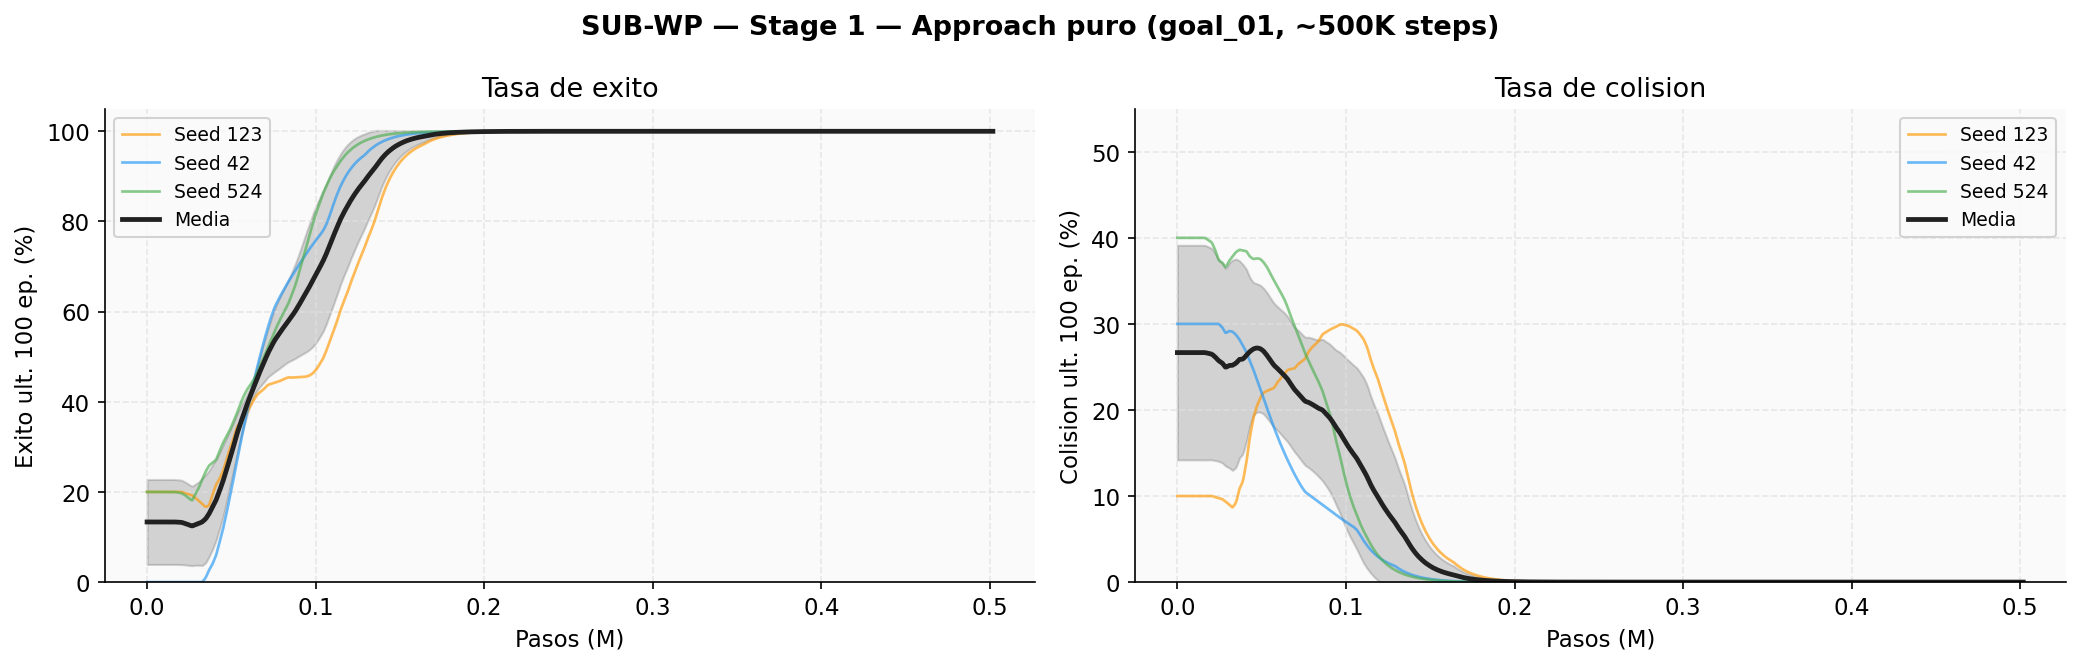

fig_subwp_stage1_01_training.png


In [2]:
plot_phase_training("stage1_subwp_s{seed}_1", "stage1", "Stage 1 — Approach puro (goal_01, ~500K steps)")

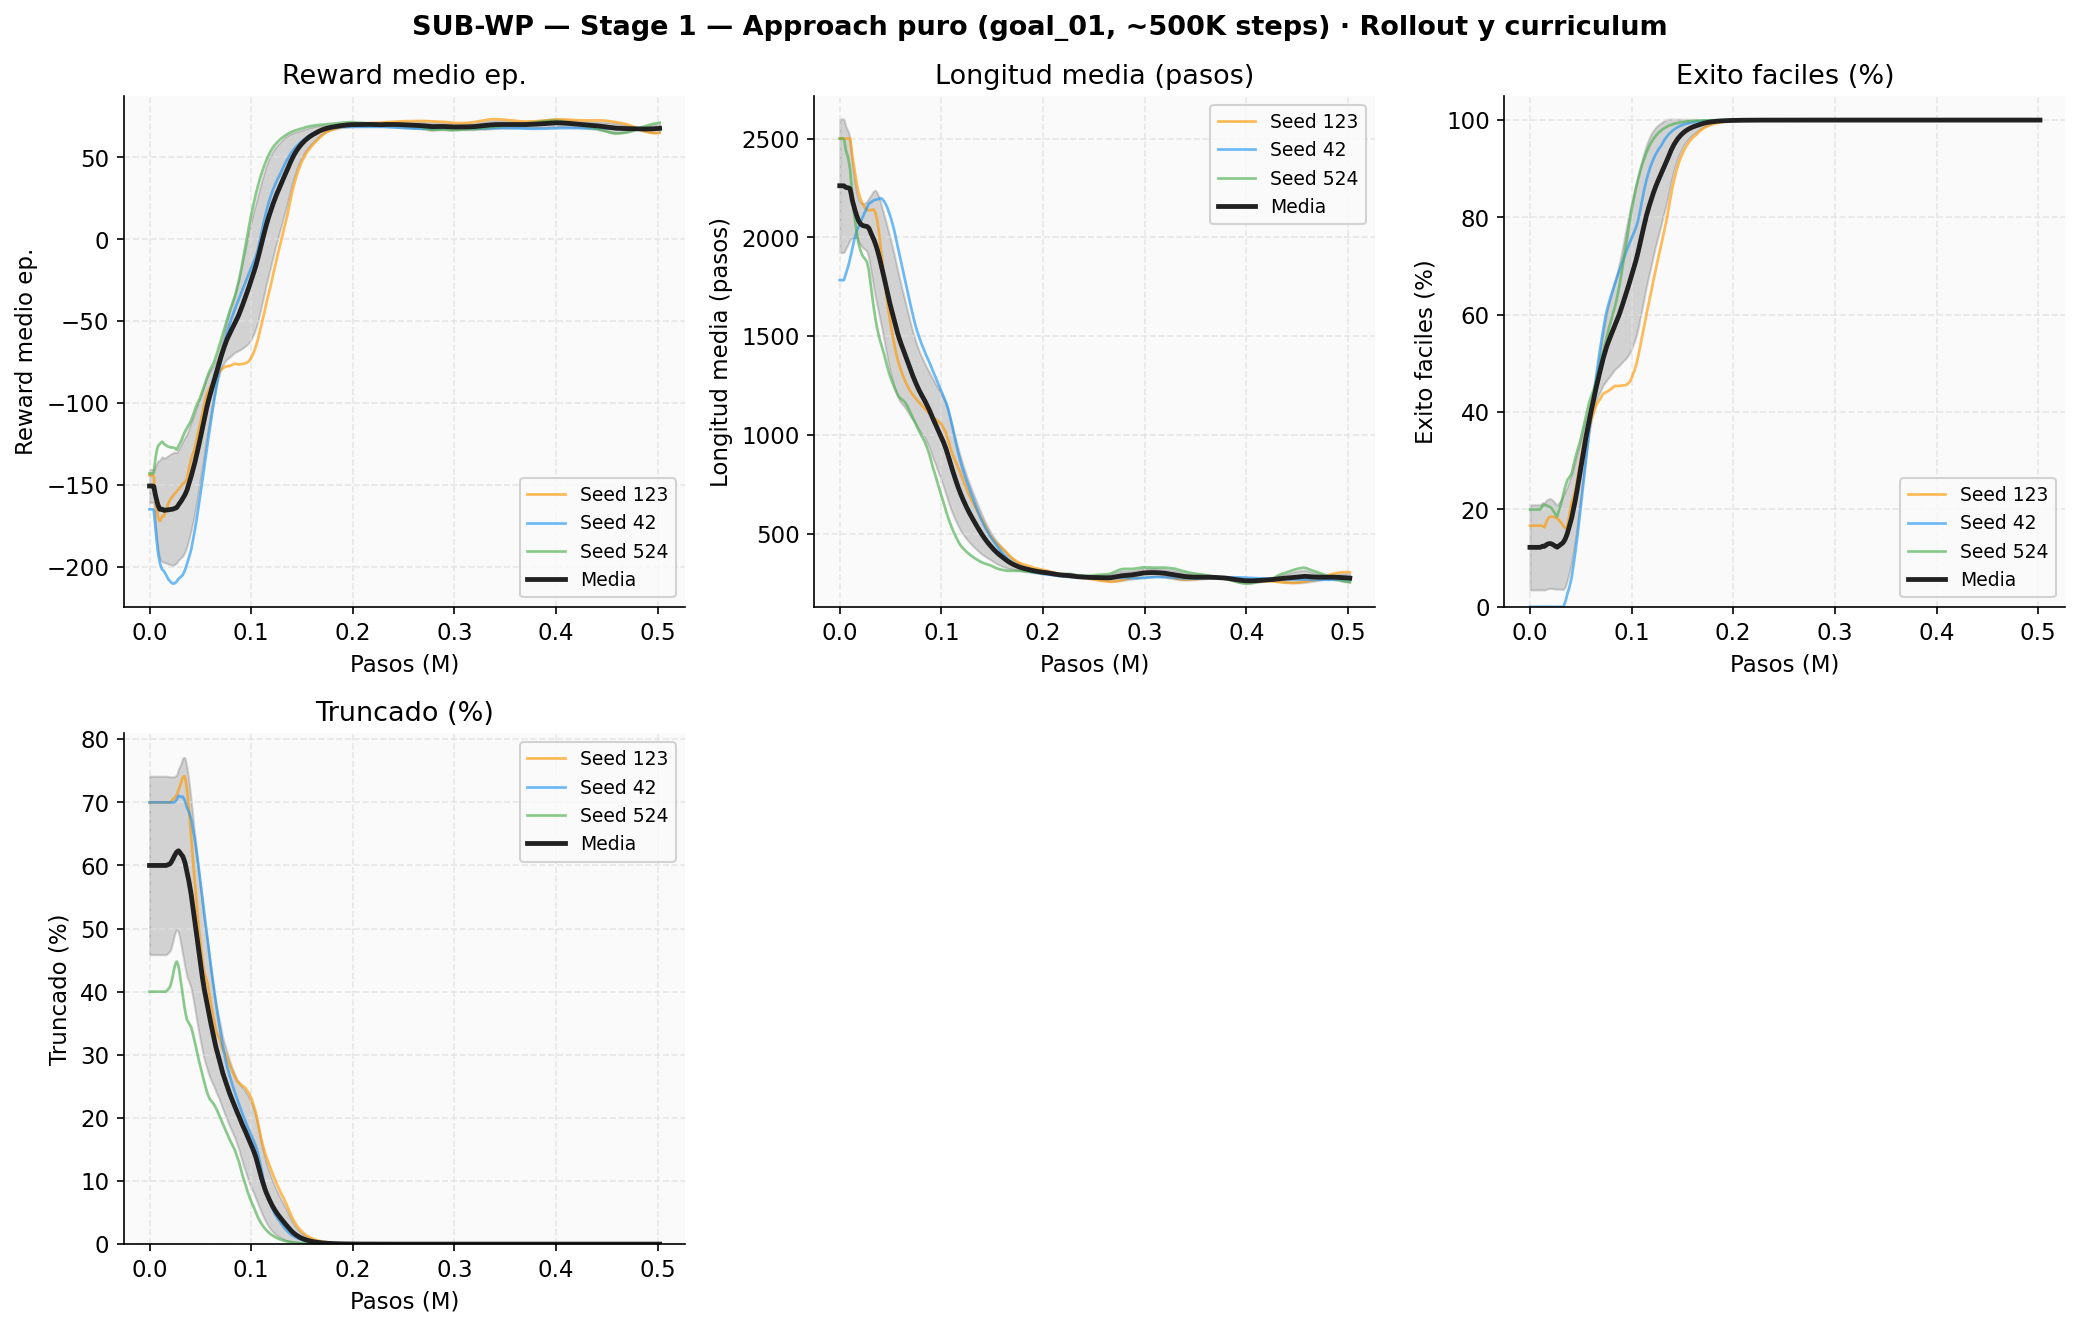

fig_subwp_stage1_02_rollout.png


In [3]:
plot_phase_rollout("stage1_subwp_s{seed}_1", "stage1", "Stage 1 — Approach puro (goal_01, ~500K steps)")

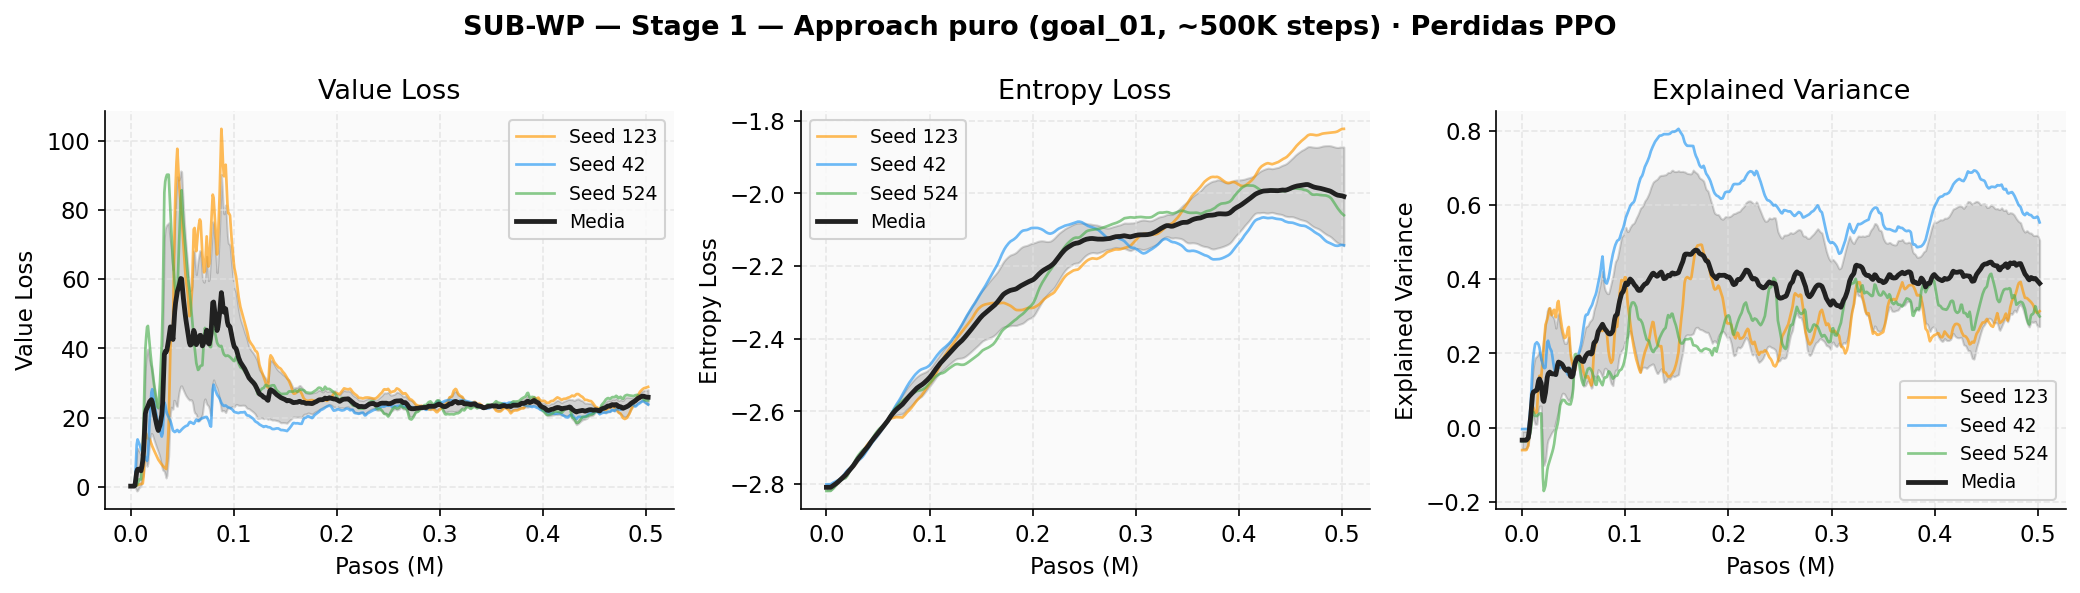

fig_subwp_stage1_03_ppo.png


In [4]:
plot_phase_ppo("stage1_subwp_s{seed}_1", "stage1", "Stage 1 — Approach puro (goal_01, ~500K steps)")

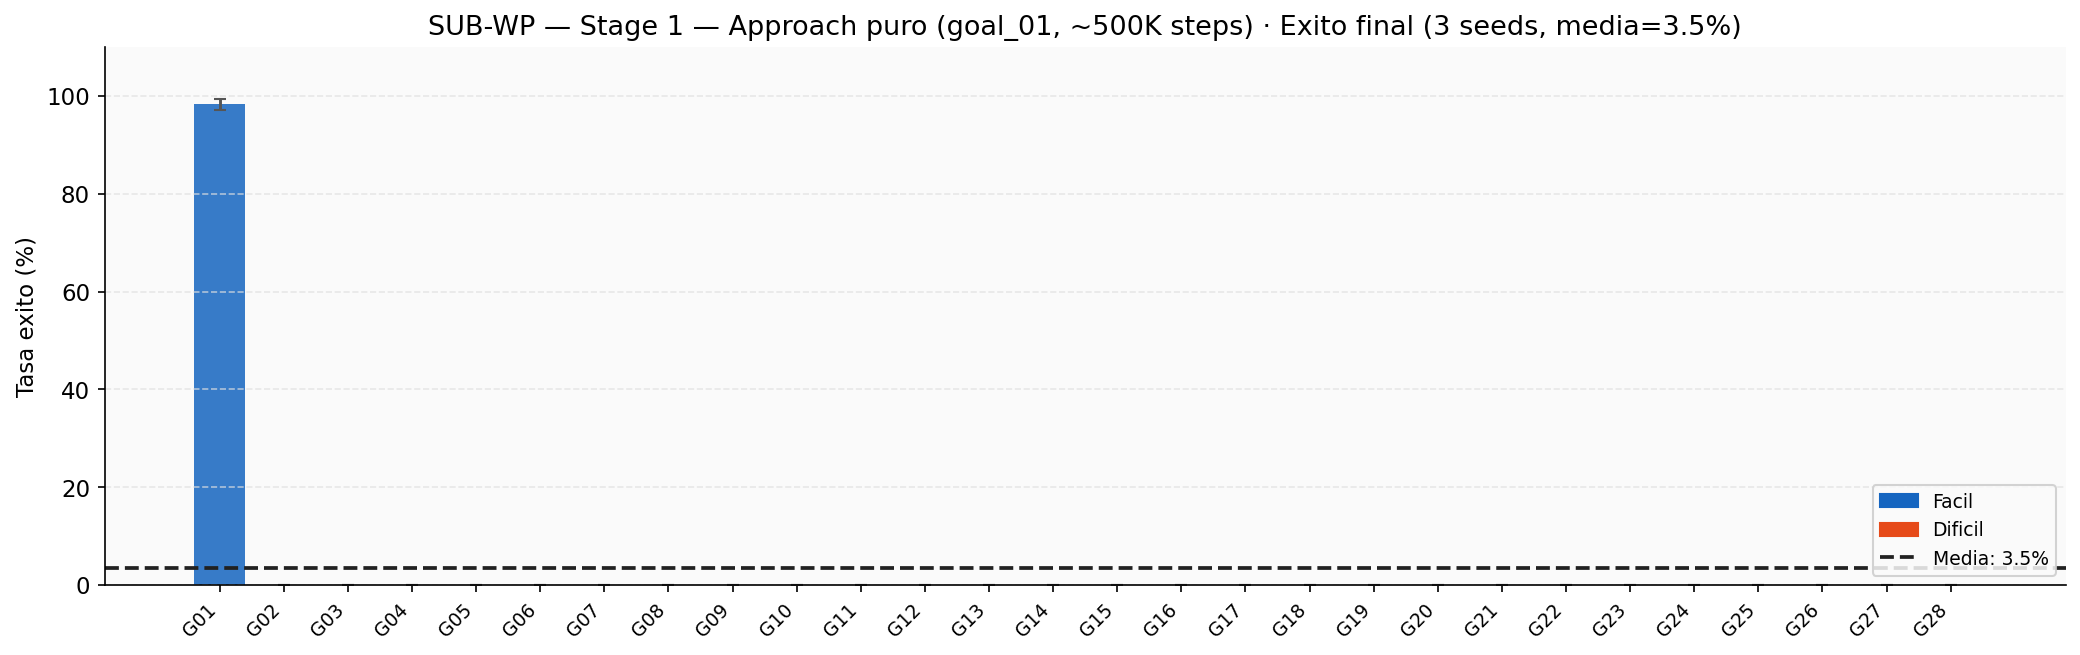

fig_subwp_stage1_04_stats.png


In [5]:
plot_phase_stats("stats_subwp_s{seed}_stage1.csv", "stage1", "Stage 1 — Approach puro (goal_01, ~500K steps)")


stage1 — Inferencia (formato historico, 3 seeds):


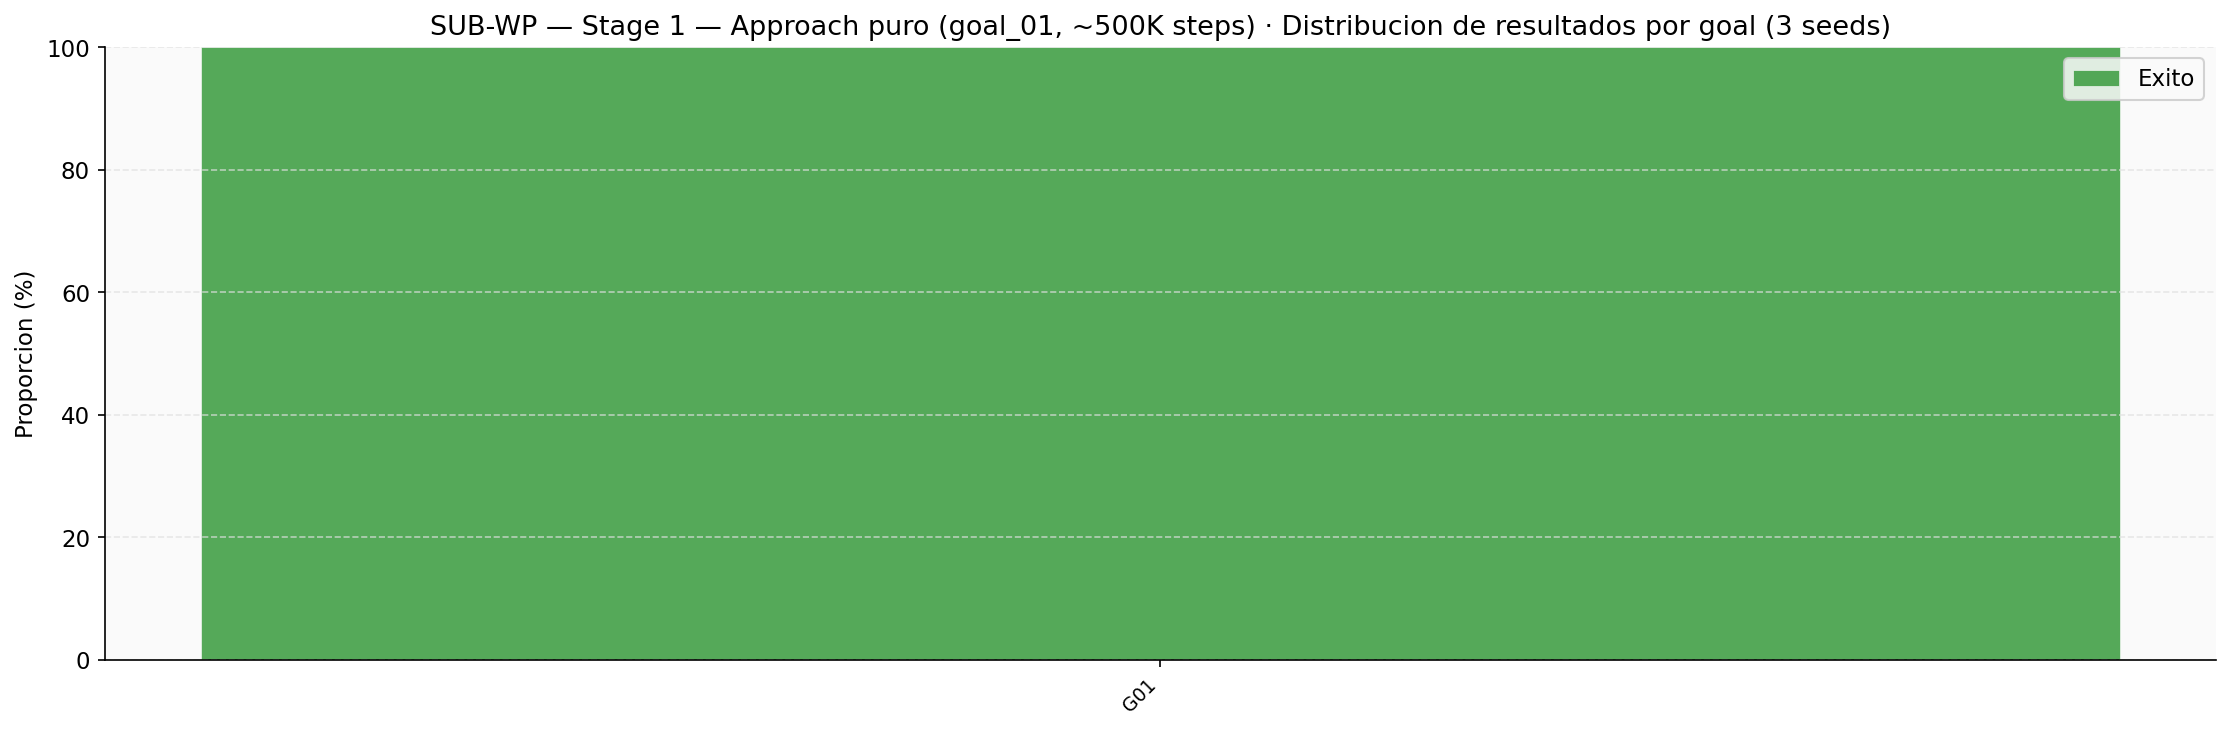

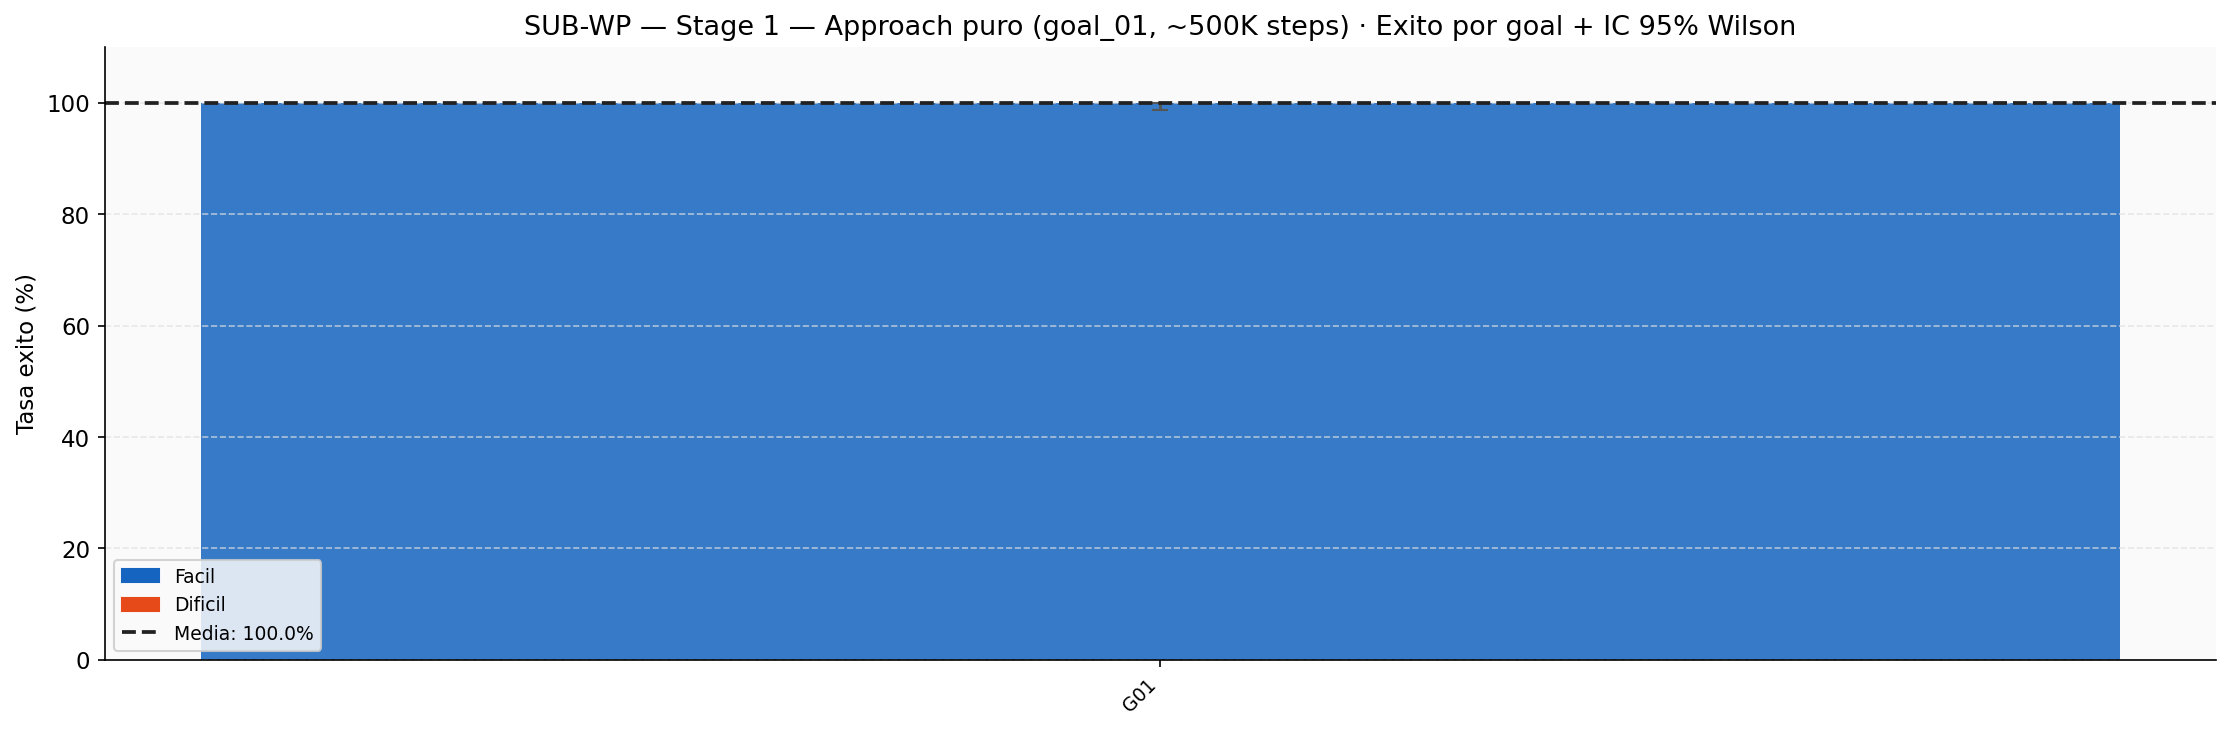

N=300 ep (3 seeds) | Exito=100.0%
  Exito                 :   300 (100.0%)  IC95%=[98.7-100.0]


In [6]:
plot_inference_old("stage1", "Stage 1 — Approach puro (goal_01, ~500K steps)")

### Stage 2 — Approach generalizado (28 goals, 4M steps)

**Objetivo**: generalizar aproximación a los **28 goals** del almacén.

Sesgo `PROB_SHELF_DIFICIL=0.7`. Episodio termina al llegar a la estantería.

**Modelo entrada**: `subwp_sXX_stage1_final` | **Salida**: `subwp_sXX_stage2_final`

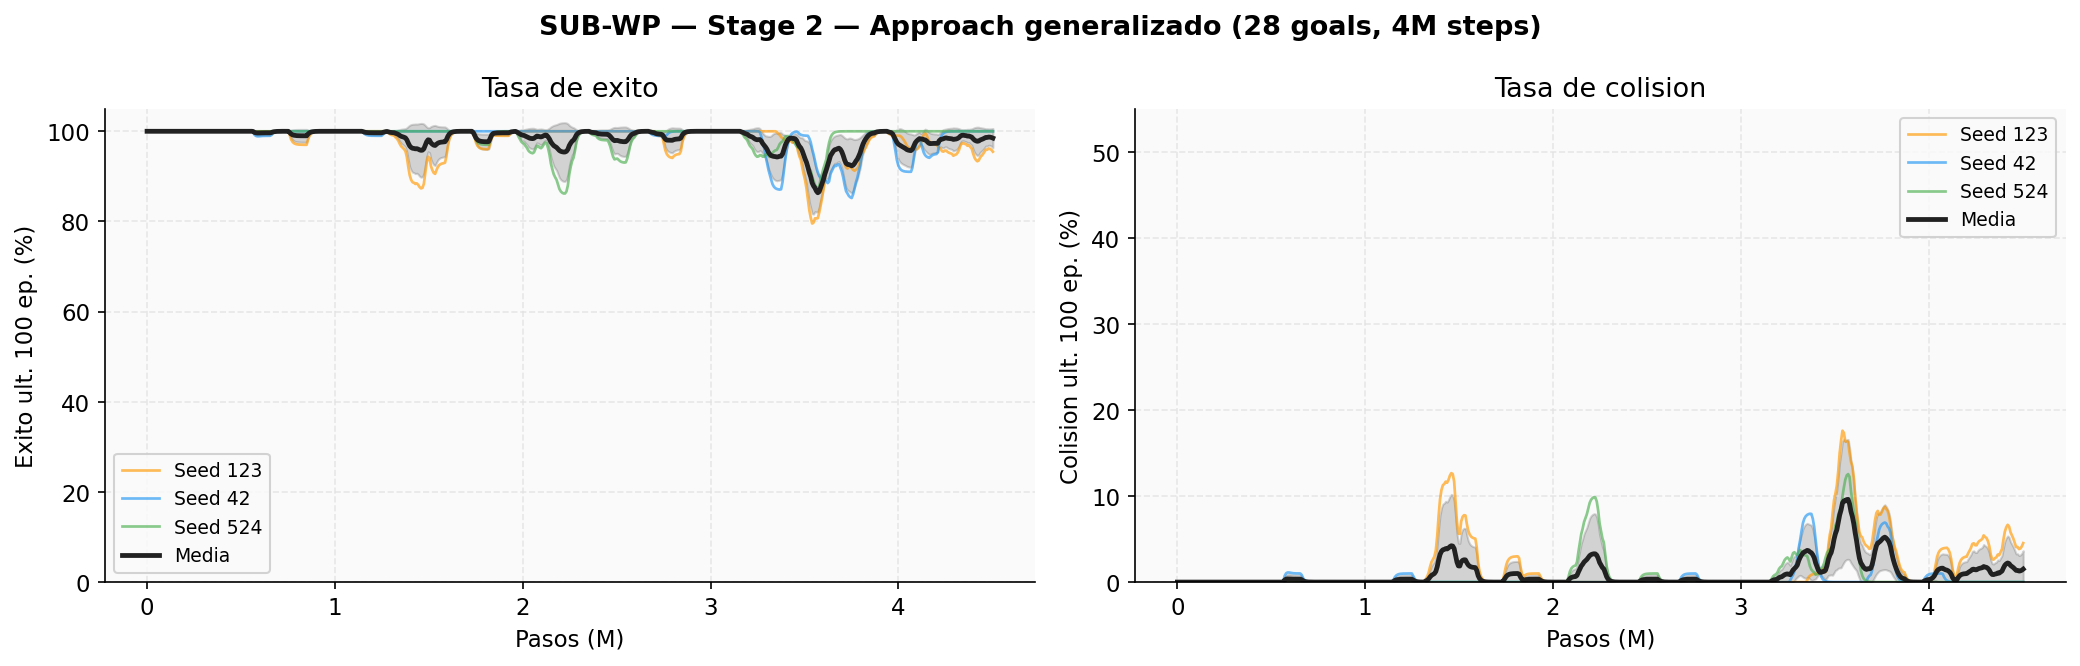

fig_subwp_stage2_01_training.png


In [7]:
plot_phase_training("stage2_subwp_s{seed}_0", "stage2", "Stage 2 — Approach generalizado (28 goals, 4M steps)")

In [ ]:
plot_phase_rollout("stage2_subwp_s{seed}_0", "stage2", "Stage 2 — Approach generalizado (28 goals, 4M steps)")

In [ ]:
plot_phase_ppo("stage2_subwp_s{seed}_0", "stage2", "Stage 2 — Approach generalizado (28 goals, 4M steps)")

In [ ]:
plot_phase_stats("stats_subwp_s{seed}_stage2.csv", "stage2", "Stage 2 — Approach generalizado (28 goals, 4M steps)")

In [ ]:
plot_inference_old("stage2", "Stage 2 — Approach generalizado (28 goals, 4M steps)")

### Stage 3 r2 — Exit con dropoff corregido (4M steps)

**Objetivo**: aprender la **fase de salida** (estantería → zona de descarga).

**Bug dropoff (r1 abandonado)**: la primera ejecución usó coordenadas `(0.0, 10.5)`
en lugar de `(-11.0, 0.0)`. Todos los episodios de exit y retorno en r1 eran inválidos.
Se reentrenó la rama completa desde Stage 2 (sufijo `_r2`).

**Modelo entrada**: `subwp_sXX_stage2_final` | **Salida**: `subwp_sXX_wp75_r2_stage3_final`

In [ ]:
plot_phase_training("stage3_r2_subwp_s{seed}_wp75_noped_0", "stage3_r2", "Stage 3 r2 — Exit con dropoff corregido (4M steps)")

In [ ]:
plot_phase_rollout("stage3_r2_subwp_s{seed}_wp75_noped_0", "stage3_r2", "Stage 3 r2 — Exit con dropoff corregido (4M steps)")

In [ ]:
plot_phase_ppo("stage3_r2_subwp_s{seed}_wp75_noped_0", "stage3_r2", "Stage 3 r2 — Exit con dropoff corregido (4M steps)")

In [ ]:
plot_phase_stats("stats_subwp_s{seed}_r2_stage3.csv", "stage3_r2", "Stage 3 r2 — Exit con dropoff corregido (4M steps)")

In [ ]:
plot_phase_estanteria("stats_subwp_s{seed}_r2_stage3.csv", "stage3_r2", "Stage 3 r2 — Exit con dropoff corregido (4M steps)")

In [ ]:
plot_inference_old("stage3_r2", "Stage 3 r2 — Exit con dropoff corregido (4M steps)")

### Stage 4 r2 — Ciclo completo 70/30 approach/exit (4M steps)

**Objetivo**: ciclo completo mezclando **70% approach / 30% exit** con dropoff correcto.

**Modelo entrada**: `subwp_sXX_wp75_r2_stage3_final` | **Salida**: `subwp_sXX_wp75_r2_stage4_final`

In [ ]:
plot_phase_training("stage4_r2_subwp_s{seed}_wp75_noped_0", "stage4_r2", "Stage 4 r2 — Ciclo completo 70/30 approach/exit (4M steps)")

In [ ]:
plot_phase_rollout("stage4_r2_subwp_s{seed}_wp75_noped_0", "stage4_r2", "Stage 4 r2 — Ciclo completo 70/30 approach/exit (4M steps)")

In [ ]:
plot_phase_ppo("stage4_r2_subwp_s{seed}_wp75_noped_0", "stage4_r2", "Stage 4 r2 — Ciclo completo 70/30 approach/exit (4M steps)")

In [ ]:
plot_phase_stats("stats_subwp_s{seed}_r2_stage4.csv", "stage4_r2", "Stage 4 r2 — Ciclo completo 70/30 approach/exit (4M steps)")

In [ ]:
plot_phase_estanteria("stats_subwp_s{seed}_r2_stage4.csv", "stage4_r2", "Stage 4 r2 — Ciclo completo 70/30 approach/exit (4M steps)")

In [ ]:
plot_inference_old("stage4_r2", "Stage 4 r2 — Ciclo completo 70/30 approach/exit (4M steps)")

### Stage 5 r2 — Segmento retorno (2M steps)

**Objetivo**: aprender el tramo **descarga → zona de espera** con dropoff correcto.

SUBWP no tiene Stage 6 estático explícito (a diferencia de STHWP). Este es el modelo
estático más completo de la rama principal. Los experimentos E2.x parten de aquí vía E2.0.

**Modelo entrada**: `subwp_sXX_wp75_r2_stage4_final` | **Salida**: `subwp_sXX_wp75_r2_stage5_final`

In [ ]:
plot_phase_training("stage5_r2_subwp_s{seed}_wp75_noped_0", "stage5_r2", "Stage 5 r2 — Segmento retorno (2M steps)")

In [ ]:
plot_phase_rollout("stage5_r2_subwp_s{seed}_wp75_noped_0", "stage5_r2", "Stage 5 r2 — Segmento retorno (2M steps)")

In [ ]:
plot_phase_ppo("stage5_r2_subwp_s{seed}_wp75_noped_0", "stage5_r2", "Stage 5 r2 — Segmento retorno (2M steps)")

In [ ]:
plot_phase_stats("stats_subwp_s{seed}_r2_stage5.csv", "stage5_r2", "Stage 5 r2 — Segmento retorno (2M steps)")

In [ ]:
plot_phase_estanteria("stats_subwp_s{seed}_r2_stage5.csv", "stage5_r2", "Stage 5 r2 — Segmento retorno (2M steps)")

In [ ]:
plot_inference_old("stage5_r2", "Stage 5 r2 — Segmento retorno (2M steps)")


---
## RAMA DINÁMICA ABANDONADA (r1 — pre-corrección dropoff)


### Stage 6 Din v1 r1 — Primera exposición peatones (1M steps) [ABANDONADO]

**Aviso**: rama abandonada. Partió del modelo r1 (bug dropoff). Incluida por completitud.

Fine-tuning con 2 peatones sobre modelo r1 (40 dims). LR=5e-5.

**Modelo salida**: `subwp_sXX_wp75_stage6_din_final`

In [ ]:
plot_phase_training("stage6_din_subwp_s{seed}_wp75_0", "din_v1_r1", "Stage 6 Din v1 r1 — Primera exposición peatones (1M steps) [ABANDONADO]")

In [ ]:
plot_phase_rollout("stage6_din_subwp_s{seed}_wp75_0", "din_v1_r1", "Stage 6 Din v1 r1 — Primera exposición peatones (1M steps) [ABANDONADO]")

In [ ]:
plot_phase_ppo("stage6_din_subwp_s{seed}_wp75_0", "din_v1_r1", "Stage 6 Din v1 r1 — Primera exposición peatones (1M steps) [ABANDONADO]")

In [ ]:
plot_phase_stats("stats_subwp_s{seed}_din_stage6.csv", "din_v1_r1", "Stage 6 Din v1 r1 — Primera exposición peatones (1M steps) [ABANDONADO]")

In [ ]:
plot_phase_estanteria("stats_subwp_s{seed}_din_stage6.csv", "din_v1_r1", "Stage 6 Din v1 r1 — Primera exposición peatones (1M steps) [ABANDONADO]")

In [ ]:
plot_inference_old("din_v1_r1", "Stage 6 Din v1 r1 — Primera exposición peatones (1M steps) [ABANDONADO]")

### Stage 6 Din v2 r1 — Obs 48-dim, peatones aleatorios (1M steps) [ABANDONADO]

**Aviso**: rama abandonada (r1). Expansion 40->48 dims con weight transplant.

**Modelo salida**: `subwp_sXX_wp75_stage6_din_v2_final`

In [ ]:
plot_phase_training("stage6_din_v2_subwp_s{seed}_wp75_1", "din_v2_r1", "Stage 6 Din v2 r1 — Obs 48-dim, peatones aleatorios (1M steps) [ABANDONADO]")

In [ ]:
plot_phase_rollout("stage6_din_v2_subwp_s{seed}_wp75_1", "din_v2_r1", "Stage 6 Din v2 r1 — Obs 48-dim, peatones aleatorios (1M steps) [ABANDONADO]")

In [ ]:
plot_phase_ppo("stage6_din_v2_subwp_s{seed}_wp75_1", "din_v2_r1", "Stage 6 Din v2 r1 — Obs 48-dim, peatones aleatorios (1M steps) [ABANDONADO]")

In [ ]:
plot_phase_stats("stats_subwp_s{seed}_wp75_din_v2_stage6.csv", "din_v2_r1", "Stage 6 Din v2 r1 — Obs 48-dim, peatones aleatorios (1M steps) [ABANDONADO]")

In [ ]:
plot_phase_estanteria("stats_subwp_s{seed}_wp75_din_v2_stage6.csv", "din_v2_r1", "Stage 6 Din v2 r1 — Obs 48-dim, peatones aleatorios (1M steps) [ABANDONADO]")

In [ ]:
plot_inference_old("din_v2_r1", "Stage 6 Din v2 r1 — Obs 48-dim, peatones aleatorios (1M steps) [ABANDONADO]")

### Stage 6 Din v2 cont r1 — Continuacion 48-dim (3M steps) [ABANDONADO]

**Aviso**: rama abandonada (r1). 3M steps adicionales sobre v2 (~4M acumulados).

**Modelo salida**: `subwp_sXX_wp75_stage6_din_v2_cont_final`

In [ ]:
plot_phase_training("stage6_din_v2_cont_subwp_s{seed}_wp75_0", "din_v2_cont_r1", "Stage 6 Din v2 cont r1 — Continuacion 48-dim (3M steps) [ABANDONADO]")

In [ ]:
plot_phase_rollout("stage6_din_v2_cont_subwp_s{seed}_wp75_0", "din_v2_cont_r1", "Stage 6 Din v2 cont r1 — Continuacion 48-dim (3M steps) [ABANDONADO]")

In [ ]:
plot_phase_ppo("stage6_din_v2_cont_subwp_s{seed}_wp75_0", "din_v2_cont_r1", "Stage 6 Din v2 cont r1 — Continuacion 48-dim (3M steps) [ABANDONADO]")

In [ ]:
plot_phase_stats("stats_subwp_s{seed}_wp75_din_v2_cont_stage6.csv", "din_v2_cont_r1", "Stage 6 Din v2 cont r1 — Continuacion 48-dim (3M steps) [ABANDONADO]")

In [ ]:
plot_phase_estanteria("stats_subwp_s{seed}_wp75_din_v2_cont_stage6.csv", "din_v2_cont_r1", "Stage 6 Din v2 cont r1 — Continuacion 48-dim (3M steps) [ABANDONADO]")

In [ ]:
plot_inference_old("din_v2_cont_r1", "Stage 6 Din v2 cont r1 — Continuacion 48-dim (3M steps) [ABANDONADO]")

### Stage 6 Din v3 r1 — Penalizacion B1 (2M steps) [ABANDONADO]

**Aviso**: rama abandonada (r1). Anyade `B1 = -0.8*exp(-2*dist_ped)` cuando `dist_ped < 2m`.

**Modelo salida**: `subwp_sXX_wp75_stage6_din_v3_final`

In [ ]:
plot_phase_training("stage6_din_v3_subwp_s{seed}_wp75_0", "din_v3_r1", "Stage 6 Din v3 r1 — Penalizacion B1 (2M steps) [ABANDONADO]")

In [ ]:
plot_phase_rollout("stage6_din_v3_subwp_s{seed}_wp75_0", "din_v3_r1", "Stage 6 Din v3 r1 — Penalizacion B1 (2M steps) [ABANDONADO]")

In [ ]:
plot_phase_ppo("stage6_din_v3_subwp_s{seed}_wp75_0", "din_v3_r1", "Stage 6 Din v3 r1 — Penalizacion B1 (2M steps) [ABANDONADO]")

In [ ]:
plot_phase_stats("stats_subwp_s{seed}_wp75_din_v3_stage6.csv", "din_v3_r1", "Stage 6 Din v3 r1 — Penalizacion B1 (2M steps) [ABANDONADO]")

In [ ]:
plot_phase_estanteria("stats_subwp_s{seed}_wp75_din_v3_stage6.csv", "din_v3_r1", "Stage 6 Din v3 r1 — Penalizacion B1 (2M steps) [ABANDONADO]")

In [ ]:
plot_inference_old("din_v3_r1", "Stage 6 Din v3 r1 — Penalizacion B1 (2M steps) [ABANDONADO]")


---
## FASE DINÁMICA VÁLIDA — Con peatones + dropoff correcto (r2)


### Stage 6 Din v3 r2 — 48-dim + B1, desde stage5_r2 (2M steps)

**Objetivo**: 48-dim con penalizacion B1, partiendo del modelo estatico correcto (r2).

Salta directamente Stage5_r2 -> Din_v3 (evita acumular entrenamiento con bug).
Weight transplant 40->48 dims. `B1 = -0.8*exp(-2*d)` cuando `dist_ped < 2m`.

**Modelo entrada**: `subwp_sXX_wp75_r2_stage5_final` (40->48 dims)
**Modelo salida**: `subwp_sXX_wp75_r2_stage6_din_v3_final`

In [ ]:
plot_phase_training("stage6_din_v3_r2_subwp_s{seed}_wp75_1", "din_v3_r2", "Stage 6 Din v3 r2 — 48-dim + B1, desde stage5_r2 (2M steps)")

In [ ]:
plot_phase_rollout("stage6_din_v3_r2_subwp_s{seed}_wp75_1", "din_v3_r2", "Stage 6 Din v3 r2 — 48-dim + B1, desde stage5_r2 (2M steps)")

In [ ]:
plot_phase_ppo("stage6_din_v3_r2_subwp_s{seed}_wp75_1", "din_v3_r2", "Stage 6 Din v3 r2 — 48-dim + B1, desde stage5_r2 (2M steps)")

In [ ]:
plot_phase_stats("stats_subwp_s{seed}_wp75_r2_din_v3_stage6.csv", "din_v3_r2", "Stage 6 Din v3 r2 — 48-dim + B1, desde stage5_r2 (2M steps)")

In [ ]:
plot_phase_estanteria("stats_subwp_s{seed}_wp75_r2_din_v3_stage6.csv", "din_v3_r2", "Stage 6 Din v3 r2 — 48-dim + B1, desde stage5_r2 (2M steps)")

In [ ]:
plot_inference_old("din_v3_r2", "Stage 6 Din v3 r2 — 48-dim + B1, desde stage5_r2 (2M steps)")

### Stage 6 Din v4 r2 — Replanning A* mid-episode (2M steps)

**Objetivo**: replanning A* dinamico durante el entrenamiento para eliminar distribution shift.

Replanning cuando `dist_perp < 0.6m`. `REPLAN_INFLATE_CELLS=3`, `REPLAN_COOLDOWN=40`.

**Modelo entrada**: `subwp_sXX_wp75_r2_stage6_din_v3_final`
**Modelo salida**: `subwp_sXX_wp75_r2_stage6_din_v4_final`

In [ ]:
plot_phase_training("stage6_din_v4_r2_subwp_s{seed}_wp75_0", "din_v4_r2", "Stage 6 Din v4 r2 — Replanning A* mid-episode (2M steps)")

In [ ]:
plot_phase_rollout("stage6_din_v4_r2_subwp_s{seed}_wp75_0", "din_v4_r2", "Stage 6 Din v4 r2 — Replanning A* mid-episode (2M steps)")

In [ ]:
plot_phase_ppo("stage6_din_v4_r2_subwp_s{seed}_wp75_0", "din_v4_r2", "Stage 6 Din v4 r2 — Replanning A* mid-episode (2M steps)")

In [ ]:
plot_phase_stats("stats_subwp_s{seed}_wp75_r2_din_v4_stage6.csv", "din_v4_r2", "Stage 6 Din v4 r2 — Replanning A* mid-episode (2M steps)")

In [ ]:
plot_phase_estanteria("stats_subwp_s{seed}_wp75_r2_din_v4_stage6.csv", "din_v4_r2", "Stage 6 Din v4 r2 — Replanning A* mid-episode (2M steps)")

In [ ]:
plot_inference_old("din_v4_r2", "Stage 6 Din v4 r2 — Replanning A* mid-episode (2M steps)")


---
## EXPERIMENTOS E1 — 1 Peatón, con supervisor (48-dim)


### E1 — 1 Peatón (3M steps)

**Objetivo**: curriculum de peatones — 1 peatón antes del segundo.

P1 oscila `x∈[-2, 4]` a `0.3-0.5 m/s`. Dims de P2 = `[0,0,0,0]`.

**Modelo entrada**: `subwp_sXX_wp75_r2_stage6_din_v3_final` (48 dims)
**Modelo salida**: `subwp_e1_1ped_sXX_final`

In [ ]:
plot_phase_training("subwp_e1_1ped_s{seed}_0", "e1_1ped", "E1 — 1 Peatón (3M steps)")

In [ ]:
plot_phase_rollout("subwp_e1_1ped_s{seed}_0", "e1_1ped", "E1 — 1 Peatón (3M steps)")

In [ ]:
plot_phase_ppo("subwp_e1_1ped_s{seed}_0", "e1_1ped", "E1 — 1 Peatón (3M steps)")

In [ ]:
plot_phase_stats("stats_subwp_e1_1ped_s{seed}_stage6.csv", "e1_1ped", "E1 — 1 Peatón (3M steps)")

In [ ]:
plot_inference_compact("subwp_infer_e1_1ped", "e1_1ped", "E1 — 1 Peatón (3M steps)", stats_pattern="stats_subwp_e1_1ped_s{seed}_stage6.csv")

### E1_pred — Observación predictiva P1 (3M steps)

**Objetivo**: prediccion de posicion futura de P1 (t+1s y t+2s), 48->52 dims.

Weight transplant desde E1. Nuevas 4 columnas = 0.

> TB log de s42 ausente para esta fase (plot con 2 seeds).

**Modelo entrada**: `subwp_e1_1ped_sXX_final` | **Salida**: `subwp_e1_pred_sXX_final`

In [ ]:
plot_phase_training("subwp_e1_pred_s{seed}_0", "e1_pred", "E1_pred — Observación predictiva P1 (3M steps)")

In [ ]:
plot_phase_rollout("subwp_e1_pred_s{seed}_0", "e1_pred", "E1_pred — Observación predictiva P1 (3M steps)")

In [ ]:
plot_phase_ppo("subwp_e1_pred_s{seed}_0", "e1_pred", "E1_pred — Observación predictiva P1 (3M steps)")

In [ ]:
plot_phase_stats("stats_subwp_e1_pred_s{seed}_stage6.csv", "e1_pred", "E1_pred — Observación predictiva P1 (3M steps)")

In [ ]:
plot_inference_compact("subwp_infer_e1_pred", "e1_pred", "E1_pred — Observación predictiva P1 (3M steps)", stats_pattern="stats_subwp_e1_pred_s{seed}_stage6.csv")

### E1.2 — Sesgo hacia goals problemáticos (2M steps)

**Objetivo**: mejorar rendimiento en clusters problemáticos.

Sesgo `70% goals 19-22+24-28 * 30% resto`. Cluster A (19-22): alto fallo col_approach.

> *Sin stats CSV de entrenamiento para esta fase.*

**Modelo entrada**: `subwp_e1_1ped_sXX_final` | **Salida**: `subwp_e1_2_sXX_final`

In [ ]:
plot_phase_training("subwp_e1_2_s{seed}_0", "e1_2", "E1.2 — Sesgo hacia goals problemáticos (2M steps)")

In [ ]:
plot_phase_rollout("subwp_e1_2_s{seed}_0", "e1_2", "E1.2 — Sesgo hacia goals problemáticos (2M steps)")

In [ ]:
plot_phase_ppo("subwp_e1_2_s{seed}_0", "e1_2", "E1.2 — Sesgo hacia goals problemáticos (2M steps)")

In [ ]:
plot_phase_stats(None, "e1_2", "E1.2 — Sesgo hacia goals problemáticos (2M steps)")

In [ ]:
plot_inference_compact("subwp_infer_e1_2", "e1_2", "E1.2 — Sesgo hacia goals problemáticos (2M steps)", stats_pattern=None)

### E1.3 — Trayectoria P1 extendida x∈[-4, 4] (2M steps)

**Objetivo**: ventanas temporales mas largas para goals 24-28.

P1: `x∈[-2, 4]` -> `x∈[-4, 4]`. Mantiene `pred_horizon=[1.0, 2.0]`.

**Modelo entrada**: `subwp_e1_2_sXX_final` | **Salida**: `subwp_e1_3_sXX_final`

In [ ]:
plot_phase_training("subwp_e1_3_s{seed}_0", "e1_3", "E1.3 — Trayectoria P1 extendida x∈[-4, 4] (2M steps)")

In [ ]:
plot_phase_rollout("subwp_e1_3_s{seed}_0", "e1_3", "E1.3 — Trayectoria P1 extendida x∈[-4, 4] (2M steps)")

In [ ]:
plot_phase_ppo("subwp_e1_3_s{seed}_0", "e1_3", "E1.3 — Trayectoria P1 extendida x∈[-4, 4] (2M steps)")

In [ ]:
plot_phase_stats("stats_subwp_e1_3_s{seed}_stage6.csv", "e1_3", "E1.3 — Trayectoria P1 extendida x∈[-4, 4] (2M steps)")

In [ ]:
plot_inference_compact("subwp_infer_e1_3", "e1_3", "E1.3 — Trayectoria P1 extendida x∈[-4, 4] (2M steps)", stats_pattern="stats_subwp_e1_3_s{seed}_stage6.csv")

### E1.4 — Patience reward + proximidad reforzada + replan agresivo (2M steps)

**Objetivo**: esperar y replanificar mas agresivamente ante P1.

- Penalizacion proximidad: `1.5*exp(-3*d)` (antes `0.8*exp(-2*d)`)
- Patience reward: `+0.4` cuando `dist_P1 < 0.8m` y baja velocidad
- `REPLAN_DIST_PERP`: 0.6->1.0m | `REPLAN_INFLATE_CELLS`: 3->4 | `REPLAN_COOLDOWN`: 40->20

**Modelo entrada**: `subwp_e1_3_sXX_final` | **Salida**: `subwp_e1_4_sXX_final`

In [ ]:
plot_phase_training("subwp_e1_4_s{seed}_0", "e1_4", "E1.4 — Patience reward + proximidad reforzada + replan agresivo (2M steps)")

In [ ]:
plot_phase_rollout("subwp_e1_4_s{seed}_0", "e1_4", "E1.4 — Patience reward + proximidad reforzada + replan agresivo (2M steps)")

In [ ]:
plot_phase_ppo("subwp_e1_4_s{seed}_0", "e1_4", "E1.4 — Patience reward + proximidad reforzada + replan agresivo (2M steps)")

In [ ]:
plot_phase_stats("stats_subwp_e1_4_s{seed}_stage6.csv", "e1_4", "E1.4 — Patience reward + proximidad reforzada + replan agresivo (2M steps)")

In [ ]:
plot_inference_compact("subwp_infer_e1_4", "e1_4", "E1.4 — Patience reward + proximidad reforzada + replan agresivo (2M steps)", stats_pattern="stats_subwp_e1_4_s{seed}_stage6.csv")

### E1.5 — Exit-corridor reward + curriculum ponderado 3x (4M steps)

**Objetivo**: resolver col_exit con P1 bloqueando el corredor de salida.

- Exit-corridor reward: `+0.6/paso` en cono 45° delante, fase exit, `dist < 2.5m`
- Curriculum: **goals 17-21, 24-28 con peso 3x** (~62% del tiempo)

**Modelo entrada**: `subwp_e1_4_sXX_final` | **Salida**: `subwp_e1_5_sXX_final`

In [ ]:
plot_phase_training("subwp_e1_5_s{seed}_0", "e1_5", "E1.5 — Exit-corridor reward + curriculum ponderado 3x (4M steps)")

In [ ]:
plot_phase_rollout("subwp_e1_5_s{seed}_0", "e1_5", "E1.5 — Exit-corridor reward + curriculum ponderado 3x (4M steps)")

In [ ]:
plot_phase_ppo("subwp_e1_5_s{seed}_0", "e1_5", "E1.5 — Exit-corridor reward + curriculum ponderado 3x (4M steps)")

In [ ]:
plot_phase_stats("stats_subwp_e1_5_s{seed}_stage6.csv", "e1_5", "E1.5 — Exit-corridor reward + curriculum ponderado 3x (4M steps)")

In [ ]:
plot_inference_compact("subwp_infer_e1_5", "e1_5", "E1.5 — Exit-corridor reward + curriculum ponderado 3x (4M steps)", stats_pattern="stats_subwp_e1_5_s{seed}_stage6.csv")


---
## EXPERIMENTOS E2 — LIDAR-only, sin supervisor


### E2.0 — Pre-entrenamiento stage6 sin peatón (2M steps) [solo SUBWP]

**Objetivo**: reconstruir ciclo completo en 40 dims antes de E2.x.

**Por que solo SUBWP necesita esto**: STHWP tiene Stage 6 estatico explicito (40 dims).
SUBWP no: su rama r2 va directamente de Stage 5 a Din_v3_r2 (48 dims).

Setup: peatón presente (LIDAR lo detecta) pero `ped_obs=False` -> sin rewards de peatón.

**Modelo entrada**: `subwp_sXX_wp75_r2_stage5_final` (40 dims)
**Modelo salida**: `subwp_e2_0_sXX_final`

In [ ]:
plot_phase_training("subwp_e2_0_s{seed}_1", "e2_0", "E2.0 — Pre-entrenamiento stage6 sin peatón (2M steps) [solo SUBWP]")

In [ ]:
plot_phase_rollout("subwp_e2_0_s{seed}_1", "e2_0", "E2.0 — Pre-entrenamiento stage6 sin peatón (2M steps) [solo SUBWP]")

In [ ]:
plot_phase_ppo("subwp_e2_0_s{seed}_1", "e2_0", "E2.0 — Pre-entrenamiento stage6 sin peatón (2M steps) [solo SUBWP]")

In [ ]:
plot_phase_stats("stats_subwp_e2_0_s{seed}_stage6.csv", "e2_0", "E2.0 — Pre-entrenamiento stage6 sin peatón (2M steps) [solo SUBWP]")

In [ ]:
plot_phase_estanteria("stats_subwp_e2_0_s{seed}_stage6.csv", "e2_0", "E2.0 — Pre-entrenamiento stage6 sin peatón (2M steps) [solo SUBWP]")

### E2.1 — Observación realista: LIDAR 5m, sin supervisor (6M steps)

**Objetivo**: navegacion realista sin supervisor — peatón solo visible por LIDAR.

- Sin supervisor: elimina pos/vel peatón (vuelve a 40 dims)
- LIDAR ampliado: 3.5m -> **5.0m** para deteccion anticipada
- Curriculum ponderado: goals dificiles con 3x probabilidad
- Reentrenamiento completo desde `subwp_e2_0_sXX_final`

**Resultado**: **82.4%** exito global (3 seeds × 28 goals × 100 ep)

In [ ]:
plot_phase_training("subwp_e2_1_s{seed}_1", "e2_1", "E2.1 — Observación realista: LIDAR 5m, sin supervisor (6M steps)")

In [ ]:
plot_phase_rollout("subwp_e2_1_s{seed}_1", "e2_1", "E2.1 — Observación realista: LIDAR 5m, sin supervisor (6M steps)")

In [ ]:
plot_phase_ppo("subwp_e2_1_s{seed}_1", "e2_1", "E2.1 — Observación realista: LIDAR 5m, sin supervisor (6M steps)")

In [ ]:
plot_phase_stats("stats_subwp_e2_1_s{seed}_stage6.csv", "e2_1", "E2.1 — Observación realista: LIDAR 5m, sin supervisor (6M steps)")

In [ ]:
# E2.1 — Panel 2x2
fig, axes = plt.subplots(2,2,figsize=(14,9))
fig.suptitle("SUB-WP E2.1 — Curvas de Entrenamiento (panel completo)", fontsize=15, fontweight="bold", y=1.01)
for ax,(tag,title,ylo,yhi) in zip(axes.flat, [
    ("stats/exito_ult100_%","Tasa Exito (ult. 100 ep.)",0,100),
    ("stats/colision_ult100_%","Tasa Colision (ult. 100 ep.)",0,100),
    ("rollout/ep_rew_mean","Reward Medio",None,None),
    ("rollout/ep_len_mean","Longitud Media (pasos)",None,None)]):
    _plot_curve(ax, load_tb_generic("subwp_e2_1_s{seed}_1",tag), title, "", ylo, yhi)
plt.tight_layout()
fig.savefig(FIGS_DIR/"fig_subwp_e2_1_panel2x2.png", bbox_inches="tight", dpi=200)
plt.show(); print("fig_subwp_e2_1_panel2x2.png")

In [ ]:
# E2.1 — Faciles vs Dificiles
fig,axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle("SUB-WP E2.1 — Exito por Dificultad", fontsize=14, fontweight="bold")
for ax,(tag,label) in zip(axes,[("stats/exito_faciles_ult100_%","Goals Faciles"),
                                  ("stats/exito_dificiles_ult100_%","Goals Dificiles")]):
    _plot_curve(ax, load_tb_generic("subwp_e2_1_s{seed}_1",tag), "%", label, 0, 105)
plt.tight_layout(); fig.savefig(FIGS_DIR/"fig_subwp_e2_1_facil_dificil.png", bbox_inches="tight", dpi=200)
plt.show()

In [ ]:
# E2.1 — PPO losses
fig,axes = plt.subplots(1,3,figsize=(15,4.5))
fig.suptitle("SUB-WP E2.1 — Perdidas PPO", fontsize=14, fontweight="bold")
for ax,(tag,label) in zip(axes,[("train/value_loss","Value Loss"),
                                  ("train/policy_gradient_loss","Policy Gradient Loss"),
                                  ("train/entropy_loss","Entropy Loss")]):
    _plot_curve(ax, load_tb_generic("subwp_e2_1_s{seed}_1",tag), "Loss", label)
plt.tight_layout(); fig.savefig(FIGS_DIR/"fig_subwp_e2_1_ppo_losses.png", bbox_inches="tight", dpi=200)
plt.show()

In [ ]:
# E2.1 — Cargar datos de inferencia
df_e21 = load_inference("subwp_infer_e2_1")
df_e21_noped = load_inference("subwp_infer_e2_1_noped")
if not df_e21.empty:
    df_e21["dificil"] = df_e21["goal_id"].map(DIFICIL_MAP)
    OUTCOMES_E21 = [o for o in ["exito","col_approach","col_exit","truncado"] if o in df_e21["resultado"].values]
    print(f"Con peatón:  {len(df_e21)} ep | Exito: {(df_e21['resultado']=='exito').mean()*100:.1f}%")
    print(f"Sin peatón:  {len(df_e21_noped)} ep | Exito: {(df_e21_noped['resultado']=='exito').mean()*100:.1f}%")

In [ ]:
# E2.1 — Stacked bars por goal
if not df_e21.empty:
    goals = sorted([g for g in df_e21["goal_id"].unique() if pd.notna(g) and str(g).startswith("goal_")], key=lambda g: int(str(g).split("_")[1]))
    totals = {g:len(df_e21[df_e21["goal_id"]==g]) for g in goals}
    x = np.arange(len(goals))
    fig,ax = plt.subplots(figsize=(15,6)); bottom=np.zeros(len(goals))
    for o in OUTCOMES_E21:
        vals=[len(df_e21[(df_e21["goal_id"]==g)&(df_e21["resultado"]==o)])/totals[g]*100 for g in goals]
        ax.bar(x,vals,bottom=bottom,color=OUT_COLORS[o],label=OUT_LABELS[o],alpha=0.9,edgecolor="white",lw=0.3)
        bottom+=np.array(vals)
    ax.set_xticks(x); ax.set_xticklabels([g.replace("goal_","G") for g in goals],rotation=45,ha="right",fontsize=9)
    ax.set_ylabel("Proporcion (%)"); ax.set_ylim(0,100)
    ax.set_title("SUB-WP E2.1 — Distribucion de resultados por goal")
    ax.legend(); ax.grid(True,axis="y"); plt.tight_layout()
    fig.savefig(FIGS_DIR/"fig_subwp_e2_1_infer_stacked.png",bbox_inches="tight",dpi=200); plt.show()

In [ ]:
# E2.1 — IC Wilson por goal
if not df_e21.empty:
    tasas,lo_s,hi_s,cols=[],[],[],[]
    for g in goals:
        k=(df_e21[df_e21["goal_id"]==g]["resultado"]=="exito").sum(); n=totals[g]
        t=k/n*100 if n>0 else 0; lo,hi=wilson_ci(k,n)
        tasas.append(t); lo_s.append(lo*100); hi_s.append(hi*100)
        cols.append(COL_DIFICIL if DIFICIL_MAP.get(g,False) else COL_FACIL)
    yerr_lo=np.maximum(np.array(tasas)-np.array(lo_s),0)
    yerr_hi=np.maximum(np.array(hi_s)-np.array(tasas),0)
    fig,ax=plt.subplots(figsize=(15,5))
    ax.bar(x,tasas,yerr=[yerr_lo,yerr_hi],color=cols,alpha=0.85,capsize=4,error_kw={"elinewidth":1.4,"ecolor":"#555"})
    gr=(df_e21["resultado"]=="exito").mean()*100
    ax.axhline(gr,color="#212121",linestyle="--",linewidth=1.8,label=f"Media: {gr:.1f}%")
    ax.set_xticks(x); ax.set_xticklabels([g.replace("goal_","G") for g in goals],rotation=45,ha="right",fontsize=9)
    ax.set_ylabel("Tasa exito (%)"); ax.set_ylim(0,110)
    ax.set_title("SUB-WP E2.1 — Tasa exito por goal + IC 95% Wilson")
    ax.legend(handles=[mpatches.Patch(color=COL_FACIL,label="Facil"),mpatches.Patch(color=COL_DIFICIL,label="Dificil"),
                        plt.Line2D([0],[0],color="#212121",ls="--",lw=1.8,label=f"Media: {gr:.1f}%")],fontsize=9)
    ax.grid(True,axis="y"); plt.tight_layout()
    fig.savefig(FIGS_DIR/"fig_subwp_e2_1_infer_ci_ped.png",bbox_inches="tight",dpi=200); plt.show()

In [ ]:
# E2.1 — Ablacion con/sin peatón
if not df_e21.empty and not df_e21_noped.empty:
    tasa_ped  =[(df_e21[df_e21["goal_id"]==g]["resultado"]=="exito").mean()*100 for g in goals]
    tasa_noped=[(df_e21_noped[df_e21_noped["goal_id"]==g]["resultado"]=="exito").mean()*100 for g in goals]
    delta=np.array(tasa_ped)-np.array(tasa_noped); w=0.38
    fig,axes=plt.subplots(1,2,figsize=(16,5))
    fig.suptitle("SUB-WP E2.1 — Comparativa con / sin peatón", fontsize=13, fontweight="bold")
    axes[0].bar(x-w/2,tasa_ped,w,color="#1565C0",alpha=0.85,label="Con peatón")
    axes[0].bar(x+w/2,tasa_noped,w,color="#78909C",alpha=0.85,label="Sin peatón")
    axes[0].set_xticks(x); axes[0].set_xticklabels([g.replace("goal_","G") for g in goals],rotation=45,ha="right",fontsize=8)
    axes[0].set_ylabel("Tasa exito (%)"); axes[0].set_ylim(0,110); axes[0].legend(); axes[0].grid(True,axis="y")
    axes[0].set_title("Tasa exito por goal")
    axes[1].bar(x,delta,color=["#E53935" if d<0 else "#43A047" for d in delta],alpha=0.85)
    axes[1].axhline(0,color="#212121",lw=1.2)
    axes[1].set_xticks(x); axes[1].set_xticklabels([g.replace("goal_","G") for g in goals],rotation=45,ha="right",fontsize=8)
    axes[1].set_ylabel("Delta pp"); axes[1].set_title("Delta (con - sin peatón)"); axes[1].grid(True,axis="y")
    plt.tight_layout(); fig.savefig(FIGS_DIR/"fig_subwp_e2_1_ablacion.png",bbox_inches="tight",dpi=200); plt.show()
    print(f"con={np.mean(tasa_ped):.1f}%  sin={np.mean(tasa_noped):.1f}%  D={np.mean(delta):+.1f} pp")

In [ ]:
# E2.1 — Heatmap
if not df_e21.empty:
    pivot = df_e21.groupby(["goal_id","seed"]).apply(lambda g: (g["resultado"]=="exito").mean()*100).unstack()
    pivot = pivot.reindex(sorted(pivot.index))
    cmap_rg = LinearSegmentedColormap.from_list("ryg",["#E53935","#FFF176","#43A047"])
    fig,ax=plt.subplots(figsize=(6,11))
    im=ax.imshow(pivot.values,aspect="auto",cmap=cmap_rg,vmin=0,vmax=100)
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels([g.replace("goal_","G") for g in pivot.index],fontsize=9)
    ax.set_title("SUB-WP E2.1 — Heatmap exito (inferencia)",pad=10)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v=pivot.values[i,j]
            if not np.isnan(v): ax.text(j,i,f"{v:.0f}",ha="center",va="center",fontsize=9,
                                         color="white" if v<40 else "black",fontweight="bold")
    plt.colorbar(im,ax=ax,label="Exito (%)",shrink=0.6); plt.tight_layout()
    fig.savefig(FIGS_DIR/"fig_subwp_e2_1_heatmap.png",bbox_inches="tight",dpi=200); plt.show()

In [ ]:
# E2.1 — Resumen estadistico
if not df_e21.empty:
    total = len(df_e21)
    print(f"{'='*60}")
    print(f"  SUB-WP E2.1 — Resumen estadistico (N={total})")
    print(f"{'='*60}")
    for o in OUTCOMES_E21:
        k=(df_e21["resultado"]==o).sum()
        lo,hi=wilson_ci(k,total)
        print(f"  {OUT_LABELS[o]:<22}: {k:>5} ({k/total*100:>5.1f}%)  IC95%=[{lo*100:.1f}-{hi*100:.1f}]")
    print(f"{'-'*60}")
    print(f"  Por dificultad:")
    for dif,label in [(False,"Faciles"),(True,"Dificiles")]:
        sub=df_e21[df_e21["dificil"]==dif]
        k=(sub["resultado"]=="exito").sum(); n=len(sub)
        lo,hi=wilson_ci(k,n)
        print(f"  {label:<22}: {k:>5}/{n:>5} ({k/n*100:>5.1f}%)  IC95%=[{lo*100:.1f}-{hi*100:.1f}]")
    print(f"{'='*60}")

### E2.2 — Replanning LIDAR dinamico (6M steps)

**Objetivo**: replanning A* usando LIDAR (sin supervisor).

Filtro de rayos `[1.5m, 4.5m]` con celda libre en mapa estatico.

**Modelo entrada**: `subwp_e2_1_sXX_final` | **Salida**: `subwp_e2_2_sXX_final`

In [ ]:
plot_phase_training("subwp_e2_2_s{seed}_1", "e2_2", "E2.2 — Replanning LIDAR dinamico (6M steps)")

In [ ]:
plot_phase_rollout("subwp_e2_2_s{seed}_1", "e2_2", "E2.2 — Replanning LIDAR dinamico (6M steps)")

In [ ]:
plot_phase_ppo("subwp_e2_2_s{seed}_1", "e2_2", "E2.2 — Replanning LIDAR dinamico (6M steps)")

In [ ]:
plot_phase_stats("stats_subwp_e2_2_s{seed}_stage6.csv", "e2_2", "E2.2 — Replanning LIDAR dinamico (6M steps)")

In [ ]:
plot_inference_compact("subwp_infer_e2_2", "e2_2", "E2.2 — Replanning LIDAR dinamico (6M steps)", stats_pattern="stats_subwp_e2_2_s{seed}_stage6.csv")

### E2.2b — Replanning LIDAR umbral corregido (6M steps)

**Corrección de E2.2**: `LIDAR_MIN_DYNAMIC` 1.5m -> **2.5m** para evitar falsos
positivos en paredes de pasillos estrechos (~2m de ancho).

**Modelo entrada**: `subwp_e2_1_sXX_final` (no E2.2) | **Salida**: `subwp_e2_2b_sXX_final`

In [ ]:
plot_phase_training("subwp_e2_2b_s{seed}_1", "e2_2b", "E2.2b — Replanning LIDAR umbral corregido (6M steps)")

In [ ]:
plot_phase_rollout("subwp_e2_2b_s{seed}_1", "e2_2b", "E2.2b — Replanning LIDAR umbral corregido (6M steps)")

In [ ]:
plot_phase_ppo("subwp_e2_2b_s{seed}_1", "e2_2b", "E2.2b — Replanning LIDAR umbral corregido (6M steps)")

In [ ]:
plot_phase_stats("stats_subwp_e2_2b_s{seed}_stage6.csv", "e2_2b", "E2.2b — Replanning LIDAR umbral corregido (6M steps)")

In [ ]:
plot_inference_compact("subwp_infer_e2_2b", "e2_2b", "E2.2b — Replanning LIDAR umbral corregido (6M steps)", stats_pattern="stats_subwp_e2_2b_s{seed}_stage6.csv")